# Block E — Confidence Calibration

**Project:** Multi-label chest X-ray classification — NIH ChestX-ray14

**Formula Reference:** `Explaination_About_DL_Formula.pdf`, Sections 13 & 14

## Pipeline:
1. Fit per-disease temperature T on **validation** (minimize NLL, T ∈ [0.05, 20]). Warn if T hits boundary.
2. Apply T to **test** logits — verify AUROC unchanged.
3. Compute ECE-15, Adaptive ECE, Brier (vs reference ȳ(1−ȳ)), NLL before/after on test.
4. Plot reliability diagrams: **Infiltration** (common), **Cardiomegaly** (medium), **Hernia** (rare).
5. Export `results/calibration.xlsx` and `results/figures/reliability_*.png`.
6. Explain when test results underperform validation (distribution shift).

**Key Note:** We divide logits by T (not multiply). AUROC and F1 unchanged because division by T > 0 preserves rank order.

## Step 0: Upload Data from Block C

Need 4 files from Block C (Training):
- `logits_val.npy`, `labels_val.npy`
- `logits_test.npy`, `labels_test.npy`

In [18]:
import os
from google.colab import files

REQUIRED = ["logits_val.npy", "labels_val.npy",
            "logits_test.npy", "labels_test.npy"]
missing = [f for f in REQUIRED if not os.path.exists(f)]

if missing:
    print(f"Missing: {missing}")
    print("Uploading...")
    uploaded = files.upload()
    for name in uploaded:
        print(f"{name}")
else:
    print("All 4 files present")

All 4 files present


## Step 1: Import Libraries

In [2]:
import warnings
import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar
from scipy.stats import rankdata
import matplotlib.pyplot as plt

print("Libraries imported")

Libraries imported


## Step 2: Constants & Math Functions (Sections 13, 14)

In [3]:
DISEASES = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
    "Mass", "Nodule", "Pneumonia", "Pneumothorax",
    "Consolidation", "Edema", "Emphysema", "Fibrosis",
    "Pleural_Thickening", "Hernia",
]
N_BINS   = 15
T_MIN    = 0.05
T_MAX    = 20.0
# Reliability diagrams: common / medium / rare
DIAGRAM_DISEASES = ["Infiltration", "Cardiomegaly", "Hernia"]

print(f"Diseases: {len(DISEASES)} | ECE bins: {N_BINS} | T ∈ [{T_MIN}, {T_MAX}]")

Diseases: 14 | ECE bins: 15 | T ∈ [0.05, 20.0]


In [4]:
def sigmoid(z):
    """Numerically-stable sigmoid."""
    z = np.asarray(z, dtype=np.float64)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    e = np.exp(z[~pos])
    out[~pos] = e / (1.0 + e)
    return out


def nll_logits(z, y):
    """NLL = mean[softplus(z) − y·z]  (Section 13)."""
    return float(np.mean(np.logaddexp(0.0, z) - y * z))


def fit_temperature(z_val, y_val):
    """
    T* = argmin_{T∈[0.05,20]} NLL(z/T, y) on validation  (Section 13).
    Returns (T, hit_lower, hit_upper) — warn if boundary hit.
    """
    res = minimize_scalar(
        lambda T: nll_logits(z_val / T, y_val),
        bounds=(T_MIN, T_MAX),
        method="bounded",
    )
    T = res.x
    hit_lo = np.isclose(T, T_MIN, atol=1e-6)
    hit_hi = np.isclose(T, T_MAX, atol=1e-6)
    return T, hit_lo, hit_hi


def auroc_score(y, s):
    """AUROC Mann–Whitney. Invariant to T > 0 scaling  (Section 10)."""
    y = np.asarray(y, dtype=np.float64)
    s = np.asarray(s, dtype=np.float64)
    P = y.sum(); N = len(y) - P
    if P == 0 or N == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y == 1].sum() - P * (P + 1) / 2) / (P * N))


def ece_equal_width(y, p, n_bins=N_BINS):
    """ECE with 15 equal-width bins  (Section 14)."""
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, edges[1:-1], right=True), 0, n_bins - 1)
    total = 0.0
    for b in range(n_bins):
        m = idx == b
        if m.any():
            total += m.mean() * abs(y[m].mean() - p[m].mean())
    return total


def ece_adaptive(y, p, n_bins=N_BINS):
    """ECE with equal-mass bins — more reliable for rare diseases  (Section 14)."""
    order = np.argsort(p, kind="mergesort")
    total = 0.0
    for part in np.array_split(order, n_bins):
        total += len(part) / len(p) * abs(y[part].mean() - p[part].mean())
    return total


def brier_score(y, p):
    """Brier = mean(p − y)²  (Section 14)."""
    return float(np.mean((np.asarray(p) - np.asarray(y)) ** 2))


def brier_reference(y):
    """Reference Brier: model always predicts prevalence → ȳ(1 − ȳ)  (Section 14)."""
    y_bar = float(y.mean())
    return y_bar * (1.0 - y_bar)


print("Math functions defined")

Math functions defined


## Step 3: Reliability Diagram Function

In [5]:
def _bin_stats(y, p, n_bins=N_BINS):
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, edges[1:-1], right=True), 0, n_bins - 1)
    pred_m, true_f, cnts = [], [], []
    for b in range(n_bins):
        m = idx == b
        if m.any():
            pred_m.append(float(p[m].mean()))
            true_f.append(float(y[m].mean()))
            cnts.append(int(m.sum()))
        else:
            pred_m.append(float((edges[b]+edges[b+1])/2))
            true_f.append(0.0)
            cnts.append(0)
    return np.array(pred_m), np.array(true_f), np.array(cnts)


def reliability_diagram(y, p_before, p_after, disease_name,
                         ece_bef, ece_aft, brier_bef, brier_aft, brier_ref,
                         n_bins=N_BINS, save_path=None):
    """
    Before/after reliability diagram with ECE & Brier annotations.
    X-axis: mean predicted probability in each bin.
    Y-axis: fraction of positives (true calibration).
    """
    prev = y.mean()
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    for ax, p, title, ece_v, brier_v in [
        (axes[0], p_before, f"{disease_name}\nBefore Calibration", ece_bef, brier_bef),
        (axes[1], p_after,  f"{disease_name}\nAfter Calibration",  ece_aft, brier_aft),
    ]:
        pm, tf, cnt = _bin_stats(y, p, n_bins)
        w = 0.85 / n_bins
        ax.plot([0,1],[0,1],"k--",lw=1.5,label="Perfect calibration")
        ax.bar(pm, tf, width=w, alpha=0.55, color="steelblue",
               edgecolor="black", linewidth=0.5, label="Model")
        for xm, yf, c in zip(pm, tf, cnt):
            if c > 0:
                ax.text(xm, yf+0.02, str(c), ha="center",
                        va="bottom", fontsize=6, color="dimgray")
        info = (
            f"ECE = {ece_v:.4f}\n"
            f"Brier = {brier_v:.4f}\n"
            f"Brier ref = {brier_ref:.4f}\n"
            f"Prevalence = {prev:.3f}"
        )
        ax.text(0.04, 0.96, info, transform=ax.transAxes,
                fontsize=8, va="top", ha="left",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow",
                          alpha=0.8, edgecolor="gray"))
        ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.10)
        ax.set_xlabel("Mean predicted probability", fontsize=10)
        ax.set_ylabel("Fraction of positives",   fontsize=10)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.grid(alpha=0.25)
        ax.legend(loc="upper left", fontsize=9)

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  → Saved: {save_path}")
    plt.show()
    plt.close(fig)


print("Reliability diagram function ready")

Reliability diagram function ready


## Step 4: Load Data

In [6]:
logits_val  = np.load("logits_val.npy").astype(np.float64)
labels_val  = np.load("labels_val.npy").astype(np.float64)
logits_test = np.load("logits_test.npy").astype(np.float64)
labels_test = np.load("labels_test.npy").astype(np.float64)

print(f"Validation : logits {logits_val.shape},  labels {labels_val.shape}")
print(f"Test       : logits {logits_test.shape}, labels {labels_test.shape}")
assert logits_val.shape[1] == 14,  "Need 14 diseases!"
assert logits_test.shape[1] == 14, "Need 14 diseases!"
print("Shapes verified")

Validation : logits (10664, 14),  labels (10664, 14)
Test       : logits (25596, 14), labels (25596, 14)
Shapes verified


## Step 5: Main Loop — Fit T + Compute Metrics

For each disease:
1. Fit T on validation (warn if T hits boundary 0.05 or 20)
2. Check AUROC unchanged on test
3. Compute ECE-15, Adaptive ECE, Brier (vs reference ȳ(1−ȳ)), NLL

In [17]:
results      = []
temperatures = []
auroc_ok_all = True

print("=" * 95)

for i, disease in enumerate(DISEASES):
    z_val  = logits_val[:, i];  y_val  = labels_val[:, i]
    z_test = logits_test[:, i]; y_test = labels_test[:, i]

    # 1. Fit T on validation
    T, hit_lo, hit_hi = fit_temperature(z_val, y_val)
    temperatures.append(T)

    if hit_lo:
        print(f"[{disease}] T={T:.4f} HIT LOWER BOUND {T_MIN}. "
              "Model may be under-confident. Do not auto-expand bounds.")
    if hit_hi:
        print(f"[{disease}] T={T:.4f} HIT UPPER BOUND {T_MAX}. "
              "Model may be over-confident. Do not auto-expand bounds.")

    # 2. AUROC invariance
    auroc_bef = auroc_score(y_test, z_test)
    auroc_aft = auroc_score(y_test, z_test / T)
    auroc_ok  = np.isclose(auroc_bef, auroc_aft, atol=1e-9)
    auroc_ok_all = auroc_ok_all and auroc_ok

    # 3. Metrics
    p_before = sigmoid(z_test)
    p_after  = sigmoid(z_test / T)

    ece_bef  = ece_equal_width(y_test, p_before)
    ece_aft  = ece_equal_width(y_test, p_after)
    aece_bef = ece_adaptive(y_test, p_before)
    aece_aft = ece_adaptive(y_test, p_after)
    brier_bef = brier_score(y_test, p_before)
    brier_aft = brier_score(y_test, p_after)
    brier_ref = brier_reference(y_test)
    nll_bef  = nll_logits(z_test, y_test)
    nll_aft  = nll_logits(z_test / T, y_test)

    results.append({
        "Disease":              disease,
        "Prevalence_test":      round(float(y_test.mean()), 6),
        "Temperature_T":        round(T, 6),
        "T_hit_lower_bound":    hit_lo,
        "T_hit_upper_bound":    hit_hi,
        "AUROC_before":         round(auroc_bef, 6),
        "AUROC_after":          round(auroc_aft, 6),
        "AUROC_unchanged":      auroc_ok,
        "NLL_before":           round(nll_bef, 6),
        "NLL_after":            round(nll_aft, 6),
        "ECE_before":           round(ece_bef, 6),
        "ECE_after":            round(ece_aft, 6),
        "AdaptiveECE_before":   round(aece_bef, 6),
        "AdaptiveECE_after":    round(aece_aft, 6),
        "Brier_before":         round(brier_bef, 6),
        "Brier_after":          round(brier_aft, 6),
        "Brier_reference_p1mp": round(brier_ref, 6),
    })

    print(
        f"[{i+1:2d}/14] {disease:20s}  T={T:6.3f}"
        f"{'⚠LO' if hit_lo else '   '}"
        f"{'⚠HI' if hit_hi else '   '}"
        f"  AUROC={auroc_bef:.4f}"
        f"  NLL {nll_bef:.4f}→{nll_aft:.4f}"
        f"  ECE {ece_bef:.4f}→{ece_aft:.4f}"
        f"  Brier {brier_bef:.4f}→{brier_aft:.4f} [ref {brier_ref:.4f}]"
        f"  {'Done' if auroc_ok else 'AUROC CHANGED!'}"
    )

print("=" * 95)

[ 1/14] Atelectasis           T= 1.076        AUROC=0.7601  NLL 0.3373→0.3348  ECE 0.0264→0.0197  Brier 0.1008→0.1005 [ref 0.1110]  Done
[ 2/14] Cardiomegaly          T= 1.074        AUROC=0.8703  NLL 0.1301→0.1278  ECE 0.0120→0.0080  Brier 0.0332→0.0330 [ref 0.0399]  Done
[ 3/14] Effusion              T= 1.157        AUROC=0.8235  NLL 0.3696→0.3662  ECE 0.0219→0.0093  Brier 0.1157→0.1152 [ref 0.1486]  Done
[ 4/14] Infiltration          T= 1.005        AUROC=0.6849  NLL 0.5304→0.5304  ECE 0.0731→0.0734  Brier 0.1763→0.1764 [ref 0.1813]  Done
[ 5/14] Mass                  T= 1.098        AUROC=0.8073  NLL 0.2050→0.2047  ECE 0.0171→0.0180  Brier 0.0554→0.0556 [ref 0.0624]  Done
[ 6/14] Nodule                T= 1.007        AUROC=0.7503  NLL 0.2136→0.2137  ECE 0.0191→0.0196  Brier 0.0567→0.0567 [ref 0.0591]  Done
[ 7/14] Pneumonia             T= 0.984        AUROC=0.7278  NLL 0.0880→0.0878  ECE 0.0055→0.0043  Brier 0.0182→0.0182 [ref 0.0183]  Done
[ 8/14] Pneumothorax          T= 1.070   

## Step 6: Verify AUROC Unchanged

In [12]:
verdict = "True" if auroc_ok_all else "False — check code"
print(f"AUROC unchanged after dividing by T: {verdict}")
if not auroc_ok_all:
    raise RuntimeError(
        "AUROC changed! Temperature scaling must not change AUROC.\n"
        "Check: T must be positive; use division not multiplication."
    )

AUROC unchanged after dividing by T: True


## Step 7: Reliability Diagrams

Plot for 3 representative diseases:
- **Infiltration** — common (~17.7%)
- **Cardiomegaly** — medium (~2.5%)
- **Hernia** — rare (~0.2%)

  → Saved: results/figures/reliability_Infiltration.png


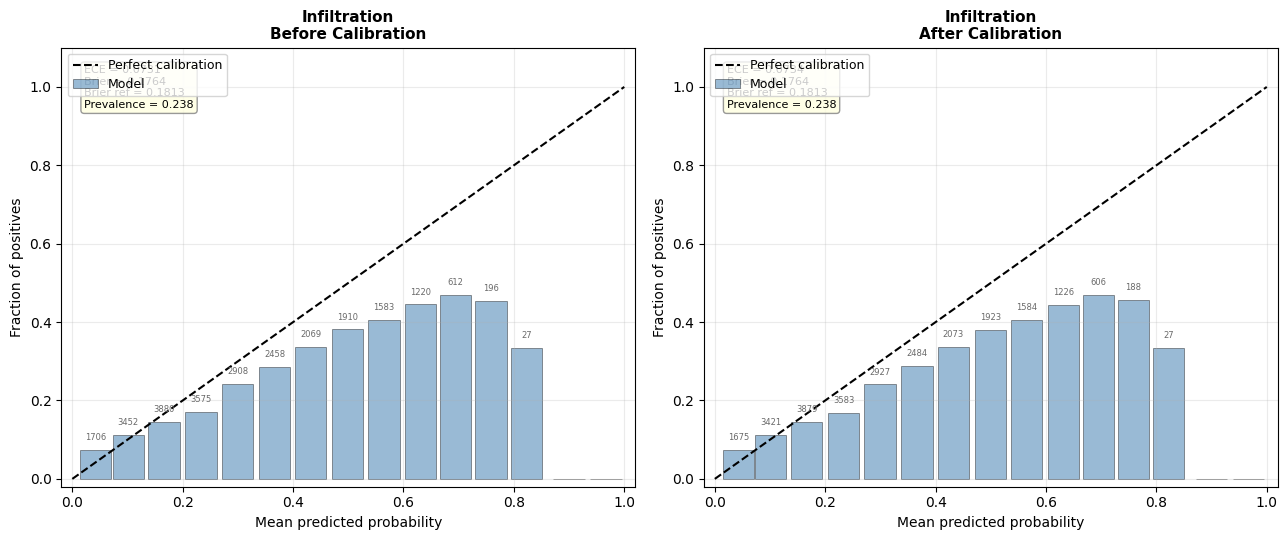

  → Saved: results/figures/reliability_Cardiomegaly.png


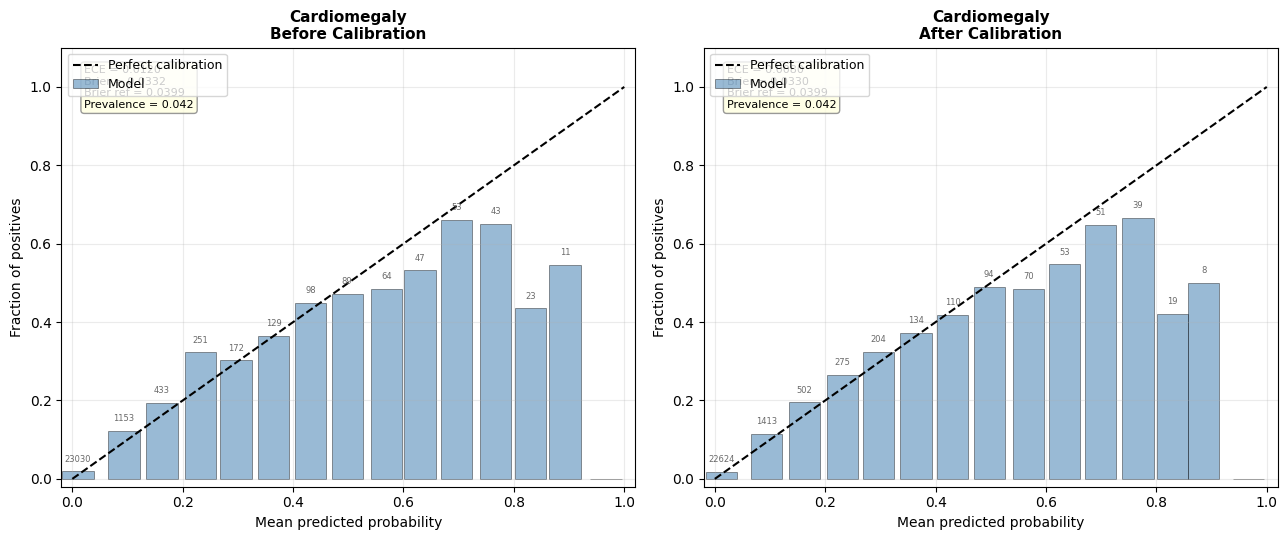

  → Saved: results/figures/reliability_Hernia.png


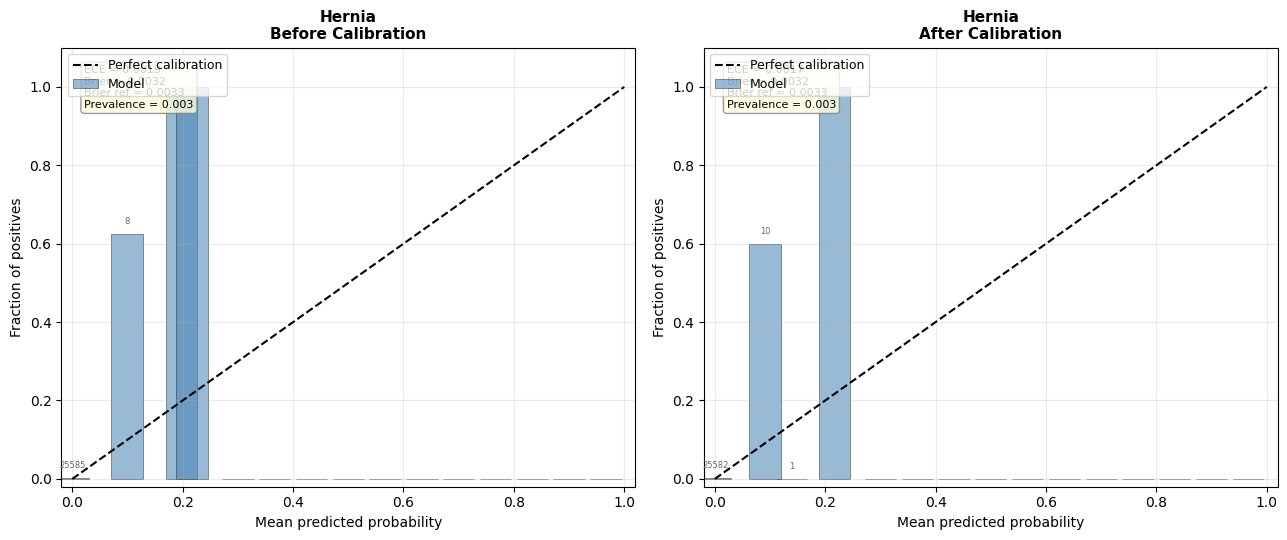

In [9]:
os.makedirs("results/figures", exist_ok=True)

for disease in DIAGRAM_DISEASES:
    idx = DISEASES.index(disease)
    T   = temperatures[idx]
    r   = results[idx]
    z_t = logits_test[:, idx]
    y_t = labels_test[:, idx]

    reliability_diagram(
        y_t,
        p_before  = sigmoid(z_t),
        p_after   = sigmoid(z_t / T),
        disease_name = disease,
        ece_bef   = r["ECE_before"],
        ece_aft   = r["ECE_after"],
        brier_bef = r["Brier_before"],
        brier_aft = r["Brier_after"],
        brier_ref = r["Brier_reference_p1mp"],
        save_path = f"results/figures/reliability_{disease}.png",
    )

## Step 8: Analyze Distribution Shift (Validation vs Test)

T is learned on validation. If disease prevalence differs between validation and test,
the T that is optimal for validation may not be optimal for test → NLL_test > NLL_val is expected.

In [21]:
shift_rows = []
for i, (disease, T) in enumerate(zip(DISEASES, temperatures)):
    z_v, y_v = logits_val[:, i], labels_val[:, i]
    z_t, y_t = logits_test[:, i], labels_test[:, i]
    prev_v  = float(y_v.mean())
    prev_t  = float(y_t.mean())
    nll_v_after = nll_logits(z_v / T, y_v)
    nll_t_after = nll_logits(z_t / T, y_t)
    shift_rows.append({
        "Disease":         disease,
        "Prev_val":        round(prev_v, 4),
        "Prev_test":       round(prev_t, 4),
        "Prev_diff_%":     round(abs(prev_v - prev_t) / max(prev_v, 1e-9) * 100, 1),
        "NLL_after_val":   round(nll_v_after, 4),
        "NLL_after_test":  round(nll_t_after, 4),
        "NLL_gap":         round(nll_t_after - nll_v_after, 4),
    })

shift_df = pd.DataFrame(shift_rows)
flagged  = shift_df[shift_df["NLL_gap"] > 0.005]

if flagged.empty:
    print(" No significant distribution shift between validation and test detected.")
else:
    print("  EXPLANATION — diseases with test underperformance vs validation:")
    print(
        "  T is learned on validation. Different disease prevalence between validation and test\n"
        "  causes T to be sub-optimal for test → NLL_after_test > NLL_after_val.\n"
        "  This is expected (distribution shift), not a code error.\n"
        "  The official NIH test set should only be used to evaluate once at the end."
    )
    print(flagged.to_string(index=False))

display(shift_df)

  EXPLANATION — diseases with test underperformance vs validation:
  T is learned on validation. Different disease prevalence between validation and test
  causes T to be sub-optimal for test → NLL_after_test > NLL_after_val.
  This is expected (distribution shift), not a code error.
  The official NIH test set should only be used to evaluate once at the end.
           Disease  Prev_val  Prev_test  Prev_diff_%  NLL_after_val  NLL_after_test  NLL_gap
       Atelectasis    0.0903     0.1272      40.8000         0.2561          0.3348   0.0787
      Cardiomegaly    0.0188     0.0416     120.8000         0.0709          0.1278   0.0569
          Effusion    0.0956     0.1816      89.9000         0.2058          0.3662   0.1605
      Infiltration    0.1574     0.2378      51.1000         0.4028          0.5304   0.1276
              Mass    0.0477     0.0669      40.1000         0.1491          0.2047   0.0556
            Nodule    0.0520     0.0631      21.2000         0.1841          0.2

,Disease,Prev_val,Prev_test,Prev_diff_%,NLL_after_val,NLL_after_test,NLL_gap
0,Atelectasis,0.0903,0.1272,40.8000,0.2561,0.3348,0.0787
1,Cardiomegaly,0.0188,0.0416,120.8000,0.0709,0.1278,0.0569
2,Effusion,0.0956,0.1816,89.9000,0.2058,0.3662,0.1605
3,Infiltration,0.1574,0.2378,51.1000,0.4028,0.5304,0.1276
4,Mass,0.0477,0.0669,40.1000,0.1491,0.2047,0.0556
5,Nodule,0.0520,0.0631,21.2000,0.1841,0.2137,0.0296
6,Pneumonia,0.0108,0.0186,72.8000,0.0551,0.0878,0.0328
7,Pneumothorax,0.0302,0.1040,244.3000,0.1055,0.2770,0.1715
8,Consolidation,0.0346,0.0709,104.9000,0.1297,0.2352,0.1055
9,Edema,0.0142,0.0361,155.2000,0.0532,0.1279,0.0747


## Step 9: Export Results to Excel

In [20]:
df = pd.DataFrame(results)

df["ECE_reduction_%"] = (
    (df["ECE_before"] - df["ECE_after"]) / df["ECE_before"] * 100
).round(1)
df["AdaptECE_reduction_%"] = (
    (df["AdaptiveECE_before"] - df["AdaptiveECE_after"]) / df["AdaptiveECE_before"] * 100
).round(1)
df["Brier_reduction_%"] = (
    (df["Brier_before"] - df["Brier_after"]) / df["Brier_before"] * 100
).round(1)
df["Brier_skill_before"] = (
    1 - df["Brier_before"] / df["Brier_reference_p1mp"]
).round(4)
df["Brier_skill_after"] = (
    1 - df["Brier_after"] / df["Brier_reference_p1mp"]
).round(4)

os.makedirs("results", exist_ok=True)
excel_path = "results/calibration.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Calibration", index=False)

    summary_rows = [
        ("Mean ECE before (test)",         df["ECE_before"].mean()),
        ("Mean ECE after (test)",          df["ECE_after"].mean()),
        ("Mean AdaptiveECE before (test)", df["AdaptiveECE_before"].mean()),
        ("Mean AdaptiveECE after (test)",  df["AdaptiveECE_after"].mean()),
        ("Mean Brier before (test)",       df["Brier_before"].mean()),
        ("Mean Brier after (test)",        df["Brier_after"].mean()),
        ("Mean Brier reference ȳ(1-ȳ)",   df["Brier_reference_p1mp"].mean()),
        ("Mean Brier skill score before",  df["Brier_skill_before"].mean()),
        ("Mean Brier skill score after",   df["Brier_skill_after"].mean()),
        ("Mean Temperature T",             df["Temperature_T"].mean()),
        ("# diseases: T hit lower bound",  int(df["T_hit_lower_bound"].sum())),
        ("# diseases: T hit upper bound",  int(df["T_hit_upper_bound"].sum())),
        ("AUROC unchanged (all 14)",       str(auroc_ok_all)),
    ]
    pd.DataFrame(summary_rows, columns=["Metric", "Value"]).to_excel(
        writer, sheet_name="Summary", index=False)

    shift_df.to_excel(writer, sheet_name="Val_vs_Test_Shift", index=False)

print(f"\n Excel: {excel_path}")
print(f" Figures: results/figures/")


 Excel: results/calibration.xlsx
 Figures: results/figures/


## Step 10: Download Results

In [19]:
from google.colab import files
files.download("results/calibration.xlsx")
for d in DIAGRAM_DISEASES:
    files.download(f"results/figures/reliability_{d}.png")
print("Download complete")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download complete


## Step 11: Full Results Table

In [16]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", "{:.4f}".format)

cols = [
    "Disease", "Prevalence_test", "Temperature_T",
    "T_hit_lower_bound", "T_hit_upper_bound",
    "AUROC_before", "AUROC_unchanged",
    "NLL_before", "NLL_after",
    "ECE_before", "ECE_after", "ECE_reduction_%",
    "AdaptiveECE_before", "AdaptiveECE_after",
    "Brier_before", "Brier_after",
    "Brier_reference_p1mp", "Brier_skill_after",
]
display(df[cols])

,Disease,Prevalence_test,Temperature_T,T_hit_lower_bound,T_hit_upper_bound,AUROC_before,AUROC_unchanged,NLL_before,NLL_after,ECE_before,ECE_after,ECE_reduction_%,AdaptiveECE_before,AdaptiveECE_after,Brier_before,Brier_after,Brier_reference_p1mp,Brier_skill_after
0,Atelectasis,0.1272,1.0756,False,False,0.7601,True,0.3373,0.3348,0.0264,0.0197,25.5000,0.0260,0.0195,0.1008,0.1005,0.1110,0.0943
1,Cardiomegaly,0.0416,1.0741,False,False,0.8703,True,0.1301,0.1278,0.0120,0.0080,33.8000,0.0095,0.0056,0.0332,0.0330,0.0399,0.1718
2,Effusion,0.1816,1.1571,False,False,0.8235,True,0.3696,0.3662,0.0219,0.0093,57.5000,0.0214,0.0079,0.1157,0.1152,0.1486,0.2249
3,Infiltration,0.2379,1.0050,False,False,0.6849,True,0.5304,0.5304,0.0731,0.0734,-0.4000,0.0742,0.0745,0.1764,0.1764,0.1813,0.0271
4,Mass,0.0669,1.0976,False,False,0.8073,True,0.2049,0.2047,0.0171,0.0180,-5.4000,0.0175,0.0197,0.0554,0.0556,0.0624,0.1084
5,Nodule,0.0631,1.0071,False,False,0.7503,True,0.2136,0.2137,0.0191,0.0196,-2.4000,0.0219,0.0224,0.0567,0.0567,0.0591,0.0408
6,Pneumonia,0.0186,0.9839,False,False,0.7278,True,0.0880,0.0878,0.0055,0.0043,20.9000,0.0075,0.0067,0.0182,0.0182,0.0183,0.0044
7,Pneumothorax,0.1040,1.0704,False,False,0.8385,True,0.2856,0.2770,0.0499,0.0445,10.8000,0.0458,0.0405,0.0800,0.0791,0.0932,0.1509
8,Consolidation,0.0709,1.0664,False,False,0.7307,True,0.2352,0.2352,0.0122,0.0120,1.5000,0.0126,0.0140,0.0635,0.0637,0.0659,0.0338
9,Edema,0.0361,1.1136,False,False,0.8359,True,0.1301,0.1279,0.0108,0.0053,50.8000,0.0096,0.0054,0.0326,0.0325,0.0348,0.0662


## Results Explanation (for Report — Member 6)

### 1. Temperature T
- **T > 1**: model is overconfident → dividing by T softens predictions toward 0.5.
- **T < 1**: model is underconfident → dividing by T sharpens predictions toward 0 or 1.
- **T hits boundary 0.05 or 20**: note in report; do not auto-expand bounds.

### 2. AUROC Unchanged
AUROC measures rank order. Dividing all logits by the same T > 0 preserves order → AUROC stays identical.
**Calibration does not improve ranking; it only makes probabilities trustworthy.**

### 3. ECE (15 equal-width bins)
ECE = Σ (n_b/n)|ȳ_b − p̄_b|. Lower = better calibration.
For rare diseases (Hernia), use **Adaptive ECE** (equal-mass bins) instead.

### 4. Brier Score vs Reference ȳ(1−ȳ)
- **Brier_reference** = ȳ(1−ȳ): Brier of a model that always predicts prevalence.
- **Brier_skill** = 1 − Brier/Brier_ref: positive = better than baseline.
- For Hernia (ȳ ≈ 0.002): Brier_ref ≈ 0.002 — never read Brier in isolation!

### 5. Test Underperforms Validation
T is learned on validation. If disease prevalence on test differs from validation (distribution shift),
the T optimal for validation is no longer optimal for test.
This is **expected behavior**, not a code error.
Use the official NIH test set to evaluate once at the very end.